# Import Libraries

In [109]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

In [110]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder, OrdinalEncoder
from sklearn.metrics import accuracy_score

In [111]:
from keras import Sequential, Model
from keras.layers import Dense, Input

# Import Dataset

In [112]:
df = pd.read_csv('customer_churn_dataset-training-master.csv')
df_test = pd.read_csv('customer_churn_dataset-testing-master.csv')

# Dataset info

In [113]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 440833 entries, 0 to 440832
Data columns (total 12 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   CustomerID         440832 non-null  float64
 1   Age                440832 non-null  float64
 2   Gender             440832 non-null  object 
 3   Tenure             440832 non-null  float64
 4   Usage Frequency    440832 non-null  float64
 5   Support Calls      440832 non-null  float64
 6   Payment Delay      440832 non-null  float64
 7   Subscription Type  440832 non-null  object 
 8   Contract Length    440832 non-null  object 
 9   Total Spend        440832 non-null  float64
 10  Last Interaction   440832 non-null  float64
 11  Churn              440832 non-null  float64
dtypes: float64(9), object(3)
memory usage: 40.4+ MB


## Null check and Remove

In [114]:
df.isnull().sum().sum(), df.duplicated().sum()

(np.int64(12), np.int64(0))

In [115]:
df[df.isnull().any(axis=1)]

,CustomerID,Age,Gender,Tenure,Usage Frequency,Support Calls,Payment Delay,Subscription Type,Contract Length,Total Spend,Last Interaction,Churn
199295,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [116]:
df.drop(df[df.isnull().any(axis=1)].index, inplace=True)

In [117]:
df.isnull().sum().sum(), df.duplicated().sum()

(np.int64(0), np.int64(0))

In [118]:
df.isna().sum()

,0
CustomerID,0
Age,0
Gender,0
Tenure,0
Usage Frequency,0
Support Calls,0
Payment Delay,0
Subscription Type,0
Contract Length,0
Total Spend,0


In [119]:
df.head()

,CustomerID,Age,Gender,Tenure,Usage Frequency,Support Calls,Payment Delay,Subscription Type,Contract Length,Total Spend,Last Interaction,Churn
0,2.0,30.0,Female,39.0,14.0,5.0,18.0,Standard,Annual,932.0,17.0,1.0
1,3.0,65.0,Female,49.0,1.0,10.0,8.0,Basic,Monthly,557.0,6.0,1.0
2,4.0,55.0,Female,14.0,4.0,6.0,18.0,Basic,Quarterly,185.0,3.0,1.0
3,5.0,58.0,Male,38.0,21.0,7.0,7.0,Standard,Monthly,396.0,29.0,1.0
4,6.0,23.0,Male,32.0,20.0,5.0,8.0,Basic,Monthly,617.0,20.0,1.0


## Remove CustomerID

In [120]:
df.drop('CustomerID', axis=1, inplace=True)

## Encode Gender, Subscription Type, Contract Length

In [121]:
df['Gender'].value_counts()

,count
Gender,
Male,250252
Female,190580


In [122]:
df['Subscription Type'].value_counts()

,count
Subscription Type,
Standard,149128
Premium,148678
Basic,143026


In [123]:
df['Contract Length'].value_counts()

,count
Contract Length,
Annual,177198
Quarterly,176530
Monthly,87104


In [124]:
encoder_columns = ['Gender', 'Subscription Type', 'Contract Length']
ohe_enocder = OneHotEncoder(drop='first', sparse_output=False)
ohe_enocder.fit_transform(df[encoder_columns])

array([[0., 0., 1., 0., 0.],
       [0., 0., 0., 1., 0.],
       [0., 0., 0., 0., 1.],
       ...,
       [1., 0., 1., 0., 1.],
       [1., 0., 1., 0., 1.],
       [1., 1., 0., 0., 1.]])

In [125]:
ohe_encoded_data = ohe_enocder.fit_transform(df[encoder_columns])
ohe_encoded_df = pd.DataFrame(ohe_encoded_data, columns=ohe_enocder.get_feature_names_out(encoder_columns))

In [126]:
df = pd.concat([df.drop(columns=encoder_columns), ohe_encoded_df], axis=1)
display(df.head())

,Age,Tenure,Usage Frequency,Support Calls,Payment Delay,Total Spend,Last Interaction,Churn,Gender_Male,Subscription Type_Premium,Subscription Type_Standard,Contract Length_Monthly,Contract Length_Quarterly
0,30.0,39.0,14.0,5.0,18.0,932.0,17.0,1.0,0.0,0.0,1.0,0.0,0.0
1,65.0,49.0,1.0,10.0,8.0,557.0,6.0,1.0,0.0,0.0,0.0,1.0,0.0
2,55.0,14.0,4.0,6.0,18.0,185.0,3.0,1.0,0.0,0.0,0.0,0.0,1.0
3,58.0,38.0,21.0,7.0,7.0,396.0,29.0,1.0,1.0,0.0,1.0,1.0,0.0
4,23.0,32.0,20.0,5.0,8.0,617.0,20.0,1.0,1.0,0.0,0.0,1.0,0.0


In [127]:
df.head()

,Age,Tenure,Usage Frequency,Support Calls,Payment Delay,Total Spend,Last Interaction,Churn,Gender_Male,Subscription Type_Premium,Subscription Type_Standard,Contract Length_Monthly,Contract Length_Quarterly
0,30.0,39.0,14.0,5.0,18.0,932.0,17.0,1.0,0.0,0.0,1.0,0.0,0.0
1,65.0,49.0,1.0,10.0,8.0,557.0,6.0,1.0,0.0,0.0,0.0,1.0,0.0
2,55.0,14.0,4.0,6.0,18.0,185.0,3.0,1.0,0.0,0.0,0.0,0.0,1.0
3,58.0,38.0,21.0,7.0,7.0,396.0,29.0,1.0,1.0,0.0,1.0,1.0,0.0
4,23.0,32.0,20.0,5.0,8.0,617.0,20.0,1.0,1.0,0.0,0.0,1.0,0.0


# Train Test Split

In [128]:
np.floor(df.shape[0]*0.5).astype(int)

np.int64(220416)

In [129]:
df=df.sample(np.floor(df.shape[0]*0.2).astype(int))
df.shape

(88166, 13)

In [130]:
X = df.drop('Churn', axis=1)
y = df['Churn']

In [131]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Scaling

In [132]:
scale = StandardScaler()
scale.fit(X_train)
X_train_scaled = scale.transform(X_train)
X_test_scaled = scale.transform(X_test)

# Simple ANN Model

![](https://drive.google.com/file/d/1gVWCeBIxNBcpIBD_Z1yBEAKjG2ub4fFQ/view)

## Steps:
1. Create `Sequencial` Instance from Keras
2. Add `Input` Layer
3. Add `Hidden1` Layer
4. Add `Hidden2` Layer
5. Add `Output` Layer
6. Build `Neural Network`
7. Set `Optimizer`, `Loss` and `Accuracy`
8. Train Model
9. Validate Accuracy

## Steps 1: Create  Sequencial Model instance

![images](https://media.geeksforgeeks.org/wp-content/uploads/20250626134023098301/Sequential-vs-Functional-API-in-Keras.webp)

```python
keras.Sequential(layers=None, trainable=True, name=None)
```


In [133]:
model = Sequential(name="my-first-keras-model")

## Step 2: Add Input Layer

In Keras, the input layer serves as the entry point for data into a neural network model. Its primary function is to define the shape and type of the data that the model expects to receive. This specification is crucial for Keras to correctly build the model and determine the necessary number of parameters in subsequent layers.

> Input
```python
keras.Input(
    shape=None,
    batch_size=None,
    dtype=None,
    sparse=None,
    ragged=None,
    batch_shape=None,
    name=None,
    tensor=None,
    optional=False,
)
```

In [134]:
input_layer = Input(shape=(X_train_scaled.shape[1], ))

## Steps 3: Add `Hidden Layer1`
A Dense layer in Keras, also known as a fully connected layer, is a fundamental building block of neural networks. It is characterized by the fact that every neuron in the dense layer receives input from all neurons of the previous layer.

> Dense Layer
```python
keras.layers.Dense(
    units,
    activation=None,
    use_bias=True,
    kernel_initializer="glorot_uniform",
    bias_initializer="zeros",
    kernel_regularizer=None,
    bias_regularizer=None,
    activity_regularizer=None,
    kernel_constraint=None,
    bias_constraint=None,
    lora_rank=None,
    lora_alpha=None,
    **kwargs
)
```

In [135]:
hiden_layer1 = Dense(units=3, activation='sigmoid')(input_layer)

## Steps 4: Add `Hidden Layer2`

In [136]:
hiden_layer2 = Dense(units=2, activation='sigmoid')(hiden_layer1)

## Step 5: Add `Output Layer`
In Keras, the output layer is the final layer in a neural network responsible for producing the model's predictions or classifications. It processes the information from the preceding layers and transforms it into the desired output format.

In [137]:
output_layer = Dense(units=1, activation='sigmoid')(hiden_layer2)

## Step 6: Build a `Neural Network` using `Model`

In [138]:
my_model = Model(inputs=input_layer, outputs=output_layer)

## Step 7: Compile the model (`Optimizer`, `Loss`, `Accuracy`)

```python
Model.compile(
    optimizer="rmsprop",
    loss=None,
    loss_weights=None,
    metrics=None,
    weighted_metrics=None,
    run_eagerly=False,
    steps_per_execution=1,
    jit_compile="auto",
    auto_scale_loss=True,
)
```

In [139]:
my_model.compile(
    optimizer='sgd',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

## Summary

In [140]:
my_model.summary()

Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_4 (InputLayer)      │ (None, 12)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 3)              │            39 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 2)              │             8 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 1)              │             3 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 50 (200.00 B)

 Trainable params: 50 (200.00 B)

 Non-trainable params: 0 (0.00 B)

## Step 8: Train Model

> Python
```python
Model.fit(
    x=None,
    y=None,
    batch_size=None,
    epochs=1,
    verbose="auto",
    callbacks=None,
    validation_split=0.0,
    validation_data=None,
    shuffle=True,
    class_weight=None,
    sample_weight=None,
    initial_epoch=0,
    steps_per_epoch=None,
    validation_steps=None,
    validation_batch_size=None,
    validation_freq=1,
)
```

In [159]:
history = my_model.fit(x=X_train_scaled, y=y_train, epochs=10, validation_split=0.2)

Epoch 1/10
1764/1764 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.8947 - loss: 0.2659 - val_accuracy: 0.8935 - val_loss: 0.2622
Epoch 2/10
1764/1764 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.8951 - loss: 0.2619 - val_accuracy: 0.8944 - val_loss: 0.2570
Epoch 3/10
1764/1764 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.8981 - loss: 0.2548 - val_accuracy: 0.8962 - val_loss: 0.2520
Epoch 4/10
1764/1764 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.8979 - loss: 0.2512 - val_accuracy: 0.8982 - val_loss: 0.2465
Epoch 5/10
1764/1764 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9008 - loss: 0.2449 - val_accuracy: 0.9018 - val_loss: 0.2405
Epoch 6/10
1764/1764 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.9051 - loss: 0.2402 - val_accuracy: 0.9049 - val_loss: 0.2339
Epoch 7/10
1764/1764 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.9059 - loss: 0.2344 - val_accuracy: 0.9083 - val_loss: 0.2273
Epoch 8/10
1764/1764 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9120 - loss: 0.2260 - 

## Weights and Biases Check

In [142]:
my_model.layers

[<InputLayer name=input_layer_4, built=True>,
 <Dense name=dense_6, built=True>,
 <Dense name=dense_7, built=True>,
 <Dense name=dense_8, built=True>]

### Input layer weights and biases

In [143]:
my_model.layers[0].get_weights()

[]

### 1st hidden layer weights and biases

In [144]:
my_model.layers[1].get_weights()

[array([[ 0.07537156,  0.7558521 ,  0.04268693],
        [ 0.0335941 , -0.0549434 ,  0.45347342],
        [ 0.03569932, -0.33380198,  0.11350587],
        [ 2.057148  ,  0.9804617 , -0.23187304],
        [ 0.7650758 ,  0.4747013 , -0.21347347],
        [-1.0288522 , -0.89495075,  0.83085775],
        [ 0.15391126,  0.42911083, -0.13523474],
        [-0.07594128, -0.49221662,  0.42687234],
        [-0.15036143,  0.06365436, -0.17332144],
        [-0.07258397,  0.21967176,  0.26310405],
        [ 1.7006581 ,  0.6067673 , -0.9518062 ],
        [-0.02140292, -0.23798461, -0.15280767]], dtype=float32),
 array([ 0.42985028, -0.00965966,  0.17539282], dtype=float32)]

### 2nd hidden layer weights and biases

In [145]:
my_model.layers[2].get_weights()

[array([[-2.7145529 , -3.1646707 ],
        [-1.7019496 , -0.89809567],
        [ 0.8264016 ,  1.0702361 ]], dtype=float32),
 array([0.8290557 , 0.59836906], dtype=float32)]

### output layer weights and biases

In [146]:
my_model.layers[3].get_weights()

[array([[-3.614715 ],
        [-3.4341018]], dtype=float32),
 array([3.357975], dtype=float32)]

## Step 9: Validation
> Python
```python
Model.evaluate(
    x=None,
    y=None,
    batch_size=None,
    verbose="auto",
    sample_weight=None,
    steps=None,
    callbacks=None,
    return_dict=False,
    **kwargs
)
```

In [147]:
test_loss, test_acc = my_model.evaluate(X_test_scaled, y_test)
print(f"Test accuracy: {test_acc:.4f}")
print(f"Test loss: {test_loss:.4f}")

552/552 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8949 - loss: 0.2666
Test accuracy: 0.8947
Test loss: 0.2666


# Prediction

In [153]:
y_log = my_model.predict(X_test_scaled)
y_pred = np.where(y_log > 0.5, 1, 0)

# Drop rows with NaN values from y_test and corresponding rows from y_pred
nan_mask = np.isnan(y_test)
y_test_cleaned = y_test[~nan_mask]
y_pred_cleaned = y_pred[~nan_mask]

accuracy_score(y_test_cleaned, y_pred_cleaned)

552/552 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step


0.8947487807644323

# Graph Plot

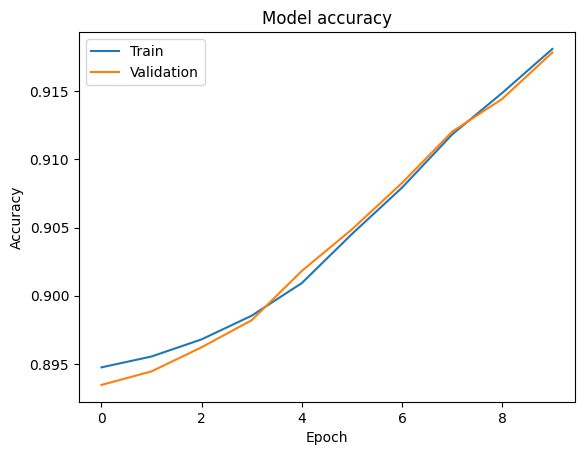

In [163]:
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('Model accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')
plt.show()

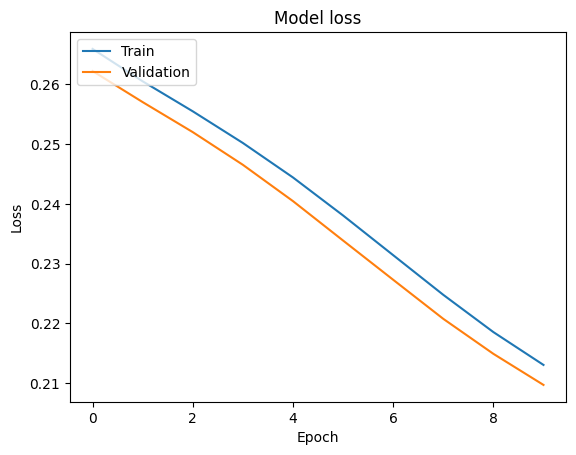

In [164]:
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('Model loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')
plt.show()